# Lecture 9
# Image Classification

As we have studied the foundamental techniques of building neural networks, let's turn our attention to image processing tasks. Image recognition is arguably the task that made the world realize the potential of deep learning.

We will approach an image recognition problem step by step. Instead of a tiny dataset of numbers, this time we will use a more extensive dataset of images.

*Readings* Chapter 7

## CIFAR-10: A Dataset of Tiny Images

CIFAR-10 is an image dataset that is often used to benchmarking the performance of machine learning models.
- It consists of 60,000 color (RGB) images of size 32x32.
- Each image is label with an integer corresponding to 1 of 10 classes: airplane, automobile, bird, cat, deer, dog, frog, horse, ship, and truck.
- The figure below gives us a taste of CIFAR-10.

<img src="https://miro.medium.com/v2/0*BdetXYemwXwOqNTs.jpg" height="300">

## Load the Dataset

Let's use the `torchvision` module to automatically download the dataset and load it as a cleection of PyTorch tensors.

In [ ]:
from torchvision import datasets

# Create a dataset for the training data.
data_path = '../data-unversioned/p1ch7/'
cifar10 = datasets.CIFAR10(data_path, train=True, download=True)

# Create a test dataset
cifar10_val = datasets.CIFAR10(data_path, train=False, download=True)

100%|██████████| 170M/170M [00:09<00:00, 18.6MB/s]


Extracting ../data-unversioned/p1ch7/cifar-10-python.tar.gz to ../data-unversioned/p1ch7/
Files already downloaded and verified


In [ ]:
type(cifar10).__mro__ # The mro method coverts the results into a list

(torchvision.datasets.cifar.CIFAR10,
 torchvision.datasets.vision.VisionDataset,
 torch.utils.data.dataset.Dataset,
 typing.Generic,
 object)

In [ ]:
# Number of images
len(cifar10), len(cifar10_val)

(50000, 10000)

In [ ]:
# Extract an image
idx = 12345
img, label = cifar10[idx]

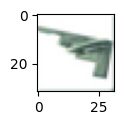

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(1, 1))
plt.imshow(img)
plt.show()

In [ ]:
class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']
print(label, class_names[label])

0 airplane


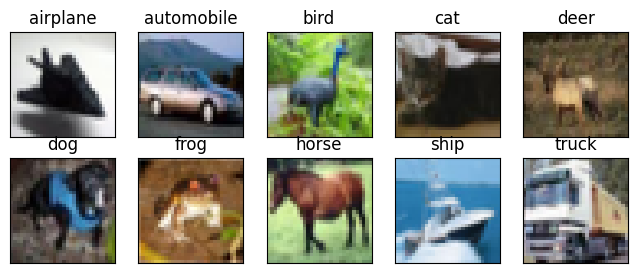

In [ ]:
# Display more images
fig = plt.figure(figsize=(8,3))
num_classes = 10
for i in range(num_classes):
    ax = fig.add_subplot(2, 5, 1 + i, xticks=[], yticks=[])
    ax.set_title(class_names[i])
    img = next(img for img, label in cifar10 if label == i)
    plt.imshow(img)
plt.show()

The input data are images, and we need to convert them into PyTorch tensors before we can build a neural network model that learns from them.

In [ ]:
# TorchVision contains many images transform operations
from torchvision import transforms
dir(transforms)

['AugMix',
 'AutoAugment',
 'AutoAugmentPolicy',
 'CenterCrop',
 'ColorJitter',
 'Compose',
 'ConvertImageDtype',
 'ElasticTransform',
 'FiveCrop',
 'GaussianBlur',
 'Grayscale',
 'InterpolationMode',
 'Lambda',
 'LinearTransformation',
 'Normalize',
 'PILToTensor',
 'Pad',
 'RandAugment',
 'RandomAdjustSharpness',
 'RandomAffine',
 'RandomApply',
 'RandomAutocontrast',
 'RandomChoice',
 'RandomCrop',
 'RandomEqualize',
 'RandomErasing',
 'RandomGrayscale',
 'RandomHorizontalFlip',
 'RandomInvert',
 'RandomOrder',
 'RandomPerspective',
 'RandomPosterize',
 'RandomResizedCrop',
 'RandomRotation',
 'RandomSolarize',
 'RandomVerticalFlip',
 'Resize',
 'TenCrop',
 'ToPILImage',
 'ToTensor',
 'TrivialAugmentWide',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 '_functional_pil',
 '_functional_tensor',
 '_presets',
 'autoaugment',
 'functional',
 'transforms']

In [ ]:
# Convert images to tensors
to_tensor = transforms.ToTensor()
img_t = to_tensor(img)
img_t.shape

torch.Size([3, 32, 32])

A CIFAR-10 image can be turned into a 3x32x32 tensor as it is a 3-channel (RGB) 32x32 image.

In [ ]:
# Apply the ToTensor transform to the entire dataset
tensor_cifar10 = datasets.CIFAR10(data_path, train=True, download=False,
                          transform=transforms.ToTensor())

In [ ]:
# Verify that each image is now represented as a tensor
img_t, label = tensor_cifar10[idx]
type(img_t)

torch.Tensor

In [ ]:
img_t.shape, img_t.dtype

(torch.Size([3, 32, 32]), torch.float32)

In [ ]:
# How many numbers are there in this image tensor?
print("In each channel: ", 32 * 32)
print("Total: ", 3 * 32 * 32)

# In comparison, what if the resolution is 1920 x 1080
print("For HD images: ", 3 * 1920 * 1080)

In each channel:  1024
Total:  3072
For HD images:  6220800


In [ ]:
# Each value in the image tensor is between 0.0 and 1.0.
img_t.min(), img_t.max()

(tensor(0.2157), tensor(1.))

torch.Size([32, 32, 3])


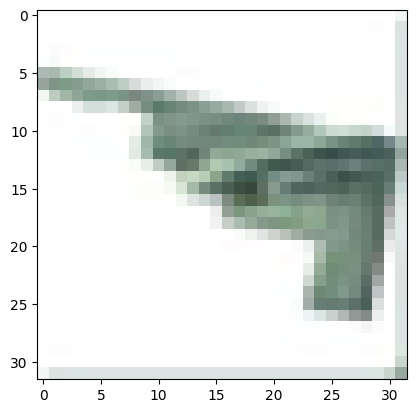

In [ ]:
# Display the image from the tensor
img = img_t.permute(1, 2, 0) # Change the order of dimensions
print(img.shape)
plt.imshow(img)
plt.show()

## Data Normalization
It is a good practice to normalize the dataset so that values from each channel has the same average (**mean**) and spread (**variance**).

One important reason for data normalization is that we tend to apply the same learning rate to all parameters, so we would like to have the optimal parameter values to be in the same range.

To achieve zero mean and unit variance, we can apply the following transform:
- new value = (old value - mean) / sqrt(variance).

The squared root of the variance value is called the **standard deviation**.

In [ ]:
# How many values do we need to represent a single 32x32 image?
print(img_t.shape)
32 * 32 * 3 # size from each dimension

torch.Size([3, 32, 32])


3072

In [ ]:
import torch
imgs = torch.stack([img_t for img_t, _ in tensor_cifar10], dim=3)
imgs.shape

torch.Size([3, 32, 32, 50000])

In [ ]:
# How many values are there in this 4D tensor?
3 * 32 * 32 * 50_000

153600000

In [ ]:
imgs.view(3, -1).mean(dim=1) # -1 is a placeholder. The actual size is 32 * 32 * 50000 = 51 million

tensor([0.4914, 0.4822, 0.4465])

In [ ]:
# How many values are being averaged in each channel?
32 * 32 * 50000

51200000

In [ ]:
# Verity that img.view(3, -1) has the desired shape
imgs.view(3, -1).shape

torch.Size([3, 51200000])

In [ ]:
imgs.view(3, -1).std(dim=1)

tensor([0.2470, 0.2435, 0.2616])

In [ ]:
# With these numbers, we can initialize the Normalize transform
transforms.Normalize((0.4915, 0.4823, 0.4468), (0.2470, 0.2435, 0.2616))

Normalize(mean=(0.4915, 0.4823, 0.4468), std=(0.247, 0.2435, 0.2616))

In [ ]:
transformed_cifar10 = datasets.CIFAR10(
    data_path, train=True, download=False,
    transform=transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.4915, 0.4823, 0.4468),
                             (0.2470, 0.2435, 0.2616))
    ]))

In [ ]:
transformed_cifar10_val = datasets.CIFAR10(
    data_path, train=False, download=False,
    transform=transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.4915, 0.4823, 0.4468),
                             (0.2470, 0.2435, 0.2616))
    ]))

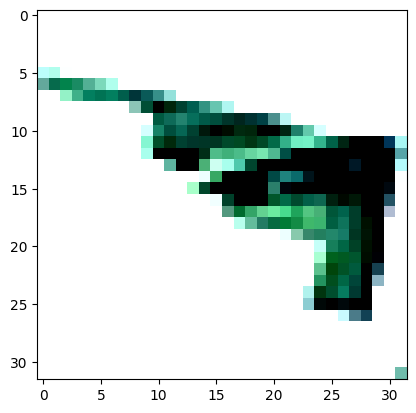

In [ ]:
# A normalized tensor can no longer be easily visualized.
img_t, label = transformed_cifar10[idx]
plt.imshow(img_t.permute(1, 2, 0))
plt.show()

## Build a Binary Classifier: Distinguishing Birds from Airplanes

In [ ]:
# Build a smaller dataset that only contains two classes
label_map = {0: 0, 2: 1}
class_names = ['airplane', 'bird']
cifar2 = [(img, label_map[label])
          for img, label in transformed_cifar10
          if label in [0, 2]]
cifar2_val = [(img, label_map[label])
              for img, label in transformed_cifar10_val
              if label in [0, 2]]

In [ ]:
len(cifar2)

10000

In [ ]:
# Build a neural network with a hidden layer of size 512.
import torch.nn as nn

n_out = 2

model = nn.Sequential(
            nn.Linear(3072, 512),
            nn.Tanh(),     # The first Linear() and Tanh() creates a dense layer
            nn.Linear(512, n_out) # This is the second dense layer.
                                  # This layer doesn't use an activation function.
        )

In [ ]:
# Estimate the number of parameters for this model:
# Layer 1: 3072 input values, 512 neurons
# Size of weight matrix: 3072 x 512
print("Weight parameters for Layer 1:", 3072 * 512)
print("Biase parameters for Layer 1:", 512)

# Layer 2: 512 input values, 2 neurons
print("Weight parameters for Layer 2:", 512 * 2)
print("Biase parameters for layer 2:", 2)

Weight parameters for Layer 1: 1572864
Biase parameters for Layer 1: 512
Weight parameters for Layer 2: 1024
Biase parameters for layer 2: 2


In [ ]:
# Represent the output as probabilities
def softmax(x):
    return torch.exp(x) / torch.exp(x).sum()

<img src="https://github.com/ch00226855/temp/blob/main/.ipynb_checkpoints/Softmax.png?raw=true" height="500">

In [ ]:
x = torch.tensor([1.0, -2.5, -3.0, 0.5, 2.0])

softmax(x)

tensor([0.2287, 0.0069, 0.0042, 0.1387, 0.6216])

In [ ]:
softmax(x).sum()

tensor(1.)

In [ ]:
# Build a model that includes the softmax function
model = nn.Sequential(
            nn.Linear(3072, 512),
            nn.Tanh(),
            nn.Linear(512, 2),
            nn.Softmax(dim=1))

Without training, we can already see the model's predictions, though the prections look very bad.

In [ ]:
# Turn the image into a 1D tensor, and put it in a batch.
img_batch = img.reshape(-1).unsqueeze(0)
print(img_batch.shape)

torch.Size([1, 3072])


In [ ]:
# Invoke the model function and get the outputs
out = model(img_batch)
out

tensor([[0.3826, 0.6174]], grad_fn=<SoftmaxBackward0>)

In [ ]:
# Turn probabilities into a class prediction
_, index = torch.max(out, dim=1)

index

tensor([1])

In [ ]:
# What if there are more than 2 classes?
out = torch.tensor([[0.1, 0.2, 0.3, 0.4, 0.0]], dtype=torch.float32)
max_val, index = torch.max(out, dim=1)
print(max_val, index)

tensor([0.4000]) tensor([3])


## Select a Loss Function
In previous weeks, we have used the MSE function as the loss function for a regression task. However, we have a better candidate function for classification tasks: the **negative log likelihood (NLL) function**.
- NLL loss is the sum of the negative log probabilities corresponding to the correct class.
- If the probability p is high (close to 100%), then -log(p) is close to zero.
- If the probability p is low (close to 0%), then -log(p) is close to infinity.

<img src="https://github.com/ch00226855/temp/blob/main/.ipynb_checkpoints/NLL.png?raw=true" height="300">

In [ ]:
# A poor prediction on the probabilities may happen to get the right class.
probabilities = torch.tensor([0.19, 0.19, 0.19, 0.19, 0.24])
# a mere 24% probability will support the right guess, even though the probability
# itself is very low.

print("Loss:", -torch.log(probabilities[4]))

# A prediction of 90% - 100%: extremely difficult
# A prediction of 50% - 60%: quite simple

Loss: tensor(1.4271)


In [ ]:
out = torch.tensor([
    [0.6, 0.4],
    [0.9, 0.1],
    [0.3, 0.7],
    [0.2, 0.8],
])
class_index = torch.tensor([0, 0, 1, 1]).unsqueeze(1)

truth = torch.zeros((4,2))
truth.scatter_(dim=1, index=class_index, value=1.0)
truth

tensor([[1., 0.],
        [1., 0.],
        [0., 1.],
        [0., 1.]])

In [ ]:
import torch.nn as nn
import torch.optim as optim

model = nn.Sequential(
            nn.Linear(3072, 512),
            nn.Tanh(),
            nn.Linear(512, 2),
            nn.LogSoftmax(dim=1))

In [ ]:
learning_rate = 1e-4 # 0.0001

optimizer = optim.SGD(model.parameters(), lr=learning_rate)

loss_fn = nn.NLLLoss()

In [ ]:
n_epochs = 5

for epoch in range(n_epochs):
    for img, label in cifar2: # Extract a single image from the dataset
        out = model(img.view(-1).unsqueeze(0))
        loss = loss_fn(out, torch.tensor([label]))

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print("Epoch: %d, Loss: %f" % (epoch, float(loss)))

Epoch: 0, Loss: 0.506650
Epoch: 1, Loss: 0.545395
Epoch: 2, Loss: 0.556006
Epoch: 3, Loss: 0.562518
Epoch: 4, Loss: 0.569245


## The Stochastic Gradient Descent (SGD) Algoithm

Looking at the training loop more closely, you may discover that we made a small yet impactiful change: for each epoch, there is an inner-loop that performs the parameter update based on a single image of the dataset.
- As there are 10,000 images in the dataset, this approach allows us to perform 10,000 updates for every pass of the dataset, instead of just 1 update.
- The gradients based on one image may not represent the overall gradient accurately, but it can greatly improved the computation efficiency.
- In practice, we do not use a single image for each update, neither do we use the entire dataset. A good tradeoff between efficiency and accuracy is achieved for a batch of 32 - 128 input instances.
- The sample size for each update should be determined before the training starts, and it is an example of the model's **hyper-parameter**.
- This variantion of the gradient descent method is called the **stochastic gradient descent method**.

<img src="https://github.com/ch00226855/temp/blob/main/.ipynb_checkpoints/SGD.png?raw=true" height="400">

In [ ]:
# We would like to split the training set into batches
batch_size = 64
print("Number of batches:", 10000 // 64)

Number of batches: 156


In [ ]:
# The DataLoader class can help us create the training batches.
train_loader = torch.utils.data.DataLoader(cifar2, batch_size=64,
                                           shuffle=True)

In [ ]:
model = nn.Sequential(
            nn.Linear(3072, 512),
            nn.Tanh(),
            nn.Linear(512, 2),
            nn.LogSoftmax(dim=1))

In [ ]:
for p in model.parameters():
    print(p.shape)

print(sum([p.numel() for p in model.parameters()]))

torch.Size([512, 3072])
torch.Size([512])
torch.Size([2, 512])
torch.Size([2])
1574402


In [ ]:
learning_rate = 1e-2

optimizer = optim.SGD(model.parameters(), lr=learning_rate)

loss_fn = nn.NLLLoss()

In [ ]:
# How many batches are there?
10000 / 64

156.25

In [ ]:
n_epochs = 5

for epoch in range(n_epochs):
    for imgs, labels in train_loader: # Extract a training batch
        outputs = model(imgs.view(imgs.shape[0], -1))
        loss = loss_fn(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print("Epoch: %d, Loss: %f" % (epoch, float(loss)))

Epoch: 0, Loss: 0.675237
Epoch: 1, Loss: 0.568619
Epoch: 2, Loss: 0.316183
Epoch: 3, Loss: 0.497166
Epoch: 4, Loss: 0.469430


## Test the Model
We see that the loss has decreased significantly, but it has not been clear to us whether the loss is low enough. Since our goal here is to correctly assign classes to images, we should evaluate the classification results directly, preferably on an independent dataset: the test set.

In [ ]:
# train_loader = torch.utils.data.DataLoader(cifar2, batch_size=64,
#                                            shuffle=False)

correct = 0
total = 0

with torch.no_grad(): # the gradient is no longer needed
    for imgs, labels in train_loader:
        outputs = model(imgs.view(imgs.shape[0], -1))
        _, predicted = torch.max(outputs, dim=1)
        total += labels.shape[0]
        correct += int((predicted == labels).sum())

print("Accuracy: %f" % (correct / total))

Accuracy: 0.827400


In [ ]:
val_loader = torch.utils.data.DataLoader(cifar2_val, batch_size=64,
                                         shuffle=False)

correct = 0
total = 0

with torch.no_grad():
    for imgs, labels in val_loader:
        outputs = model(imgs.view(imgs.shape[0], -1))
        _, predicted = torch.max(outputs, dim=1)
        total += labels.shape[0]
        correct += int((predicted == labels).sum())

print("Accuracy: %f" % (correct / total))

Accuracy: 0.808000


## Improve Performance

The performance if our first neural network model is not great, but it is already quite a lot better than random guessing. **What can we do to improve its performance?**

In [ ]:
# Add more layers to the model
model = nn.Sequential(
            nn.Linear(3072, 1024),
            nn.Tanh(),
            nn.Linear(1024, 512),
            nn.Tanh(),
            nn.Linear(512, 128),
            nn.Tanh(),
            nn.Linear(128, 2),
            nn.LogSoftmax(dim=1))

In [ ]:
# A model that is too large will overfit the training data.
for p in model.parameters():
    print(p.shape)

sum([p.numel() for p in model.parameters()])

torch.Size([1024, 3072])
torch.Size([1024])
torch.Size([512, 1024])
torch.Size([512])
torch.Size([128, 512])
torch.Size([128])
torch.Size([2, 128])
torch.Size([2])


3737474

In [ ]:
learning_rate = 1e-2

optimizer = optim.SGD(model.parameters(), lr=learning_rate)

loss_fn = nn.NLLLoss()

In [ ]:
# Model fine-tuning
# n_epochs = 5
n_epochs = 25

for epoch in range(n_epochs):
    for imgs, labels in train_loader:
        outputs = model(imgs.view(imgs.shape[0], -1))
        loss = loss_fn(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    # Calculate the test accuracy after each epoch
    correct = 0
    total = 0

    with torch.no_grad():
        for imgs, labels in val_loader:
            outputs = model(imgs.view(imgs.shape[0], -1))
            _, predicted = torch.max(outputs, dim=1)
            total += labels.shape[0]
            correct += int((predicted == labels).sum())
    print("Epoch: %d, Loss: %f, Test Accuracy: %.4f"
          % (epoch, float(loss), correct / total))

Epoch: 0, Loss: 0.589124, Test Accuracy: 0.8010
Epoch: 1, Loss: 0.469266, Test Accuracy: 0.8015
Epoch: 2, Loss: 0.336634, Test Accuracy: 0.7915
Epoch: 3, Loss: 0.547683, Test Accuracy: 0.8085
Epoch: 4, Loss: 0.251342, Test Accuracy: 0.8105
Epoch: 5, Loss: 0.430266, Test Accuracy: 0.7985
Epoch: 6, Loss: 0.435821, Test Accuracy: 0.8150
Epoch: 7, Loss: 0.296113, Test Accuracy: 0.7645
Epoch: 8, Loss: 0.515348, Test Accuracy: 0.7100
Epoch: 9, Loss: 0.465312, Test Accuracy: 0.7655
Epoch: 10, Loss: 0.279416, Test Accuracy: 0.7115
Epoch: 11, Loss: 0.500064, Test Accuracy: 0.7885
Epoch: 12, Loss: 0.328431, Test Accuracy: 0.7920
Epoch: 13, Loss: 0.636440, Test Accuracy: 0.8115
Epoch: 14, Loss: 0.245251, Test Accuracy: 0.7680
Epoch: 15, Loss: 0.438293, Test Accuracy: 0.7970
Epoch: 16, Loss: 0.151574, Test Accuracy: 0.8145
Epoch: 17, Loss: 0.521995, Test Accuracy: 0.8070
Epoch: 18, Loss: 0.509624, Test Accuracy: 0.7070
Epoch: 19, Loss: 0.369413, Test Accuracy: 0.6920
Epoch: 20, Loss: 0.566161, Tes

In [ ]:
# What is the training accuracy at this point?
correct = 0
total = 0

with torch.no_grad(): # the gradient is no longer needed
    for imgs, labels in train_loader:
        outputs = model(imgs.view(imgs.shape[0], -1))
        _, predicted = torch.max(outputs, dim=1)
        total += labels.shape[0]
        correct += int((predicted == labels).sum())

print("Accuracy on the training set: %f" % (correct / total))

Accuracy on the training set: 0.839000


In [ ]:
correct = 0
total = 0

with torch.no_grad():
    for imgs, labels in val_loader:
        outputs = model(imgs.view(imgs.shape[0], -1))
        _, predicted = torch.max(outputs, dim=1)
        total += labels.shape[0]
        correct += int((predicted == labels).sum())

print("Test Accuracy: %f" % (correct / total))

Test Accuracy: 0.775500


## Build a Multi-Class Classifier

Can we build a classifier that can identify all 10 classes?

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms

In [ ]:
# create a training dataloader
data_path = '../data-unversioned/p1ch7/'

transformed_cifar10 = datasets.CIFAR10(
    data_path, train=True, download=True,
    transform=transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.4915, 0.4823, 0.4468),
                             (0.2470, 0.2435, 0.2616))
    ]))
train_loader = torch.utils.data.DataLoader(transformed_cifar10, batch_size=64,
                                         shuffle=True)

Files already downloaded and verified


In [ ]:
# Build a neural network model
model = nn.Sequential(
            nn.Linear(3072, 512),
            nn.Tanh(),
            nn.Linear(512, 256),
            nn.Tanh(),
            nn.Linear(256, 128),
            nn.Tanh(),
            nn.Linear(128, 10),
            nn.LogSoftmax(dim=1))

In [ ]:
# Build a optimizer and a loss function
learning_rate = 1e-2

optimizer = optim.Adam(model.parameters(), lr=learning_rate) # ADAM is an improved version of gradient descent

loss_fn = nn.NLLLoss()

In [ ]:
# Train the model
import numpy as np

n_epochs = 5

for epoch in range(n_epochs):
    all_losses = []
    for imgs, labels in train_loader:
        outputs = model(imgs.view(imgs.shape[0], -1))
        loss = loss_fn(outputs, labels)
        all_losses.append(loss.detach().numpy())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print("Epoch: %d, Loss: %f" % (epoch, np.mean(all_losses)))

Epoch: 0, Loss: 2.022214
Epoch: 1, Loss: 2.017994
Epoch: 2, Loss: 2.025393
Epoch: 3, Loss: 2.018991
Epoch: 4, Loss: 2.023228


In [ ]:
# Evaluate the model

transformed_cifar10_test = datasets.CIFAR10(
    data_path, train=False, download=False,
    transform=transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.4915, 0.4823, 0.4468),
                             (0.2470, 0.2435, 0.2616))
    ]))
test_loader = torch.utils.data.DataLoader(transformed_cifar10_test, batch_size=64,
                                         shuffle=True)

correct = 0
total = 0

with torch.no_grad():
    for imgs, labels in train_loader:
        outputs = model(imgs.view(imgs.shape[0], -1))
        _, predicted = torch.max(outputs, dim=1)
        total += labels.shape[0]
        correct += int((predicted == labels).sum())

print("Test Accuracy: %f" % (correct / total))

Test Accuracy: 0.269420
